## ECG ink removal - simple histogram methods

We keep the same histogram method.
The only change is the input image.

We now:
- load a **clean** ECG image (`0001`)
- generate a **synthetic ink** image from that clean image
- apply **global histogram matching**
- apply the **local block histogram correction**
- compare the results with MAE

### Why synthetic ink
This removes padding and alignment issues.
The clean image and the synthetic ink image have the same size.

### Method
1. **Global histogram matching**: match the synthetic ink histogram to the clean histogram.
2. **Local block histograms**: in each block, detect the local excess of dark pixels and correct only that excess.

### Goal
This notebook keeps the histogram idea unchanged.
So you can compare it fairly with the closing notebook and the Wiener notebook on the same synthetic problem.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------
# Configuration
# ---------------------------------
base_path = Path("../../data/sample")

ecg_ids = ["10140238", "11842146"]
clean_scan = "0001"

# Synthetic ink settings.
# Keep them close to the other notebooks if you want an easier comparison.
SEEDS = {
    "10140238": 7,
    "11842146": 19,
}
N_STROKES = 15
N_BLOBS = 8
N_SMUDGES = 5

# Histogram method settings.
BLOCK_SIZE = 8
BIN_WIDTH = 8
DARK_MAX = 96
VALUE_MARGIN = 8


# ---------------------------------
# Basic I/O
# ---------------------------------
def load_gray_image(ecg_id, scan_type):
    path = base_path / ecg_id / f"{ecg_id}-{scan_type}.png"
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(
            f"Could not load image: {path}\n"
            "Update base_path so it points to the folder that contains the ECG images."
        )
    return img.astype(np.float32) / 255.0, path


def to_u8(img):
    return np.clip(np.round(img * 255.0), 0, 255).astype(np.uint8)


# ---------------------------------
# Synthetic ink
# ---------------------------------
def generate_random_ink_from_clean(clean_img, seed=7, n_strokes=14, n_blobs=10, n_smudges=4):
    rng = np.random.default_rng(seed)
    h, w = clean_img.shape

    stroke_layer = np.zeros((h, w), dtype=np.float32)
    blob_layer = np.zeros((h, w), dtype=np.float32)
    smudge_layer = np.zeros((h, w), dtype=np.float32)

    # Dark thin strokes.
    for _ in range(n_strokes):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        length = int(rng.integers(min(h, w) // 30, min(h, w) // 8))
        angle = float(rng.uniform(0, 2 * np.pi))
        x2 = int(np.clip(x1 + length * np.cos(angle), 0, w - 1))
        y2 = int(np.clip(y1 + length * np.sin(angle), 0, h - 1))
        thickness = int(rng.integers(2, 8))
        value = float(rng.uniform(0.18, 0.45))
        cv2.line(stroke_layer, (x1, y1), (x2, y2), value, thickness, lineType=cv2.LINE_AA)

    # Compact blobs.
    for _ in range(n_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(4, w // 80), max(8, w // 25))),
            int(rng.integers(max(4, h // 80), max(8, h // 25))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.10, 0.60))
        cv2.ellipse(blob_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    # Broad faint smudges.
    for _ in range(n_smudges):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(20, w // 25), max(40, w // 10))),
            int(rng.integers(max(20, h // 25), max(40, h // 10))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.03, 0.50))
        cv2.ellipse(smudge_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    blob_layer = cv2.GaussianBlur(blob_layer, (0, 0), sigmaX=3, sigmaY=3)
    smudge_layer = cv2.GaussianBlur(smudge_layer, (0, 0), sigmaX=11, sigmaY=11)

    darkening = np.clip(stroke_layer + blob_layer + smudge_layer, 0.0, 0.99)
    synthetic_ink = np.clip(clean_img - darkening, 0.0, 1.0)
    true_ink_mask = darkening > 0.03
    return synthetic_ink, darkening, true_ink_mask


# ---------------------------------
# Histogram helpers
# ---------------------------------
def masked_hist_u8(img_u8, mask=None):
    vals = img_u8[mask] if mask is not None else img_u8.ravel()
    hist = np.bincount(vals, minlength=256).astype(np.float64)
    return hist


def cdf_from_hist(hist):
    cdf = hist.cumsum()
    if cdf[-1] == 0:
        return cdf
    return cdf / cdf[-1]


def histogram_match_gray(source, reference, source_mask=None, reference_mask=None):
    src = to_u8(source)
    ref = to_u8(reference)

    h_src = masked_hist_u8(src, source_mask)
    h_ref = masked_hist_u8(ref, reference_mask)

    cdf_src = cdf_from_hist(h_src)
    cdf_ref = cdf_from_hist(h_ref)

    lut = np.zeros(256, dtype=np.uint8)
    j = 0
    for i in range(256):
        while j < 255 and cdf_ref[j] < cdf_src[i]:
            j += 1
        lut[i] = j

    out = src.copy()
    if source_mask is None:
        out = lut[out]
    else:
        out[source_mask] = lut[out[source_mask]]
    return out.astype(np.float32) / 255.0, h_src, h_ref


# ---------------------------------
# Metrics
# ---------------------------------
def masked_mae(a, b, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


# ---------------------------------
# Local block histogram correction
# ---------------------------------
def block_excess_dark_correction(
    clean_img,
    ink_img,
    valid_mask,
    block_size=32,
    bin_width=8,
    dark_max=96,
    value_margin=8,
):
    clean_u8 = to_u8(clean_img)
    work_u8 = to_u8(ink_img).copy()

    H, W = clean_u8.shape
    n_bins = 256 // bin_width
    dark_bins = min(n_bins, dark_max // bin_width + 1)

    changed_mask = np.zeros((H, W), dtype=bool)

    for y0 in range(0, H, block_size):
        y1 = min(y0 + block_size, H)
        for x0 in range(0, W, block_size):
            x1 = min(x0 + block_size, W)

            ys = slice(y0, y1)
            xs = slice(x0, x1)

            v = valid_mask[ys, xs]
            if v.sum() < max(8, block_size // 2):
                continue

            c_block = clean_u8[ys, xs]
            w_block = work_u8[ys, xs]

            c_vals = c_block[v]
            w_vals = w_block[v]

            h_c = np.bincount(c_vals // bin_width, minlength=n_bins)
            h_w = np.bincount(w_vals // bin_width, minlength=n_bins)

            excess = np.maximum(h_w[:dark_bins] - h_c[:dark_bins], 0)
            n_excess = int(excess.sum())
            if n_excess <= 0:
                continue

            score = c_block.astype(np.int16) - w_block.astype(np.int16)

            candidate_mask = (
                v
                & (w_block <= dark_max)
                & (score >= value_margin)
            )

            cand_rc = np.argwhere(candidate_mask)
            if len(cand_rc) == 0:
                continue

            cand_scores = score[cand_rc[:, 0], cand_rc[:, 1]]
            order = np.argsort(-cand_scores)
            chosen = cand_rc[order[:min(n_excess, len(cand_rc))]]

            for rr, cc in chosen:
                w_block[rr, cc] = c_block[rr, cc]
                changed_mask[y0 + rr, x0 + cc] = True

            work_u8[ys, xs] = w_block

    return work_u8.astype(np.float32) / 255.0, changed_mask


def plot_histograms(clean_img, ink_img, global_img, block_img, mask, title):
    clean_u8 = to_u8(clean_img)
    ink_u8 = to_u8(ink_img)
    global_u8 = to_u8(global_img)
    block_u8 = to_u8(block_img)

    h_clean = masked_hist_u8(clean_u8, mask)
    h_ink = masked_hist_u8(ink_u8, mask)
    h_global = masked_hist_u8(global_u8, mask)
    h_block = masked_hist_u8(block_u8, mask)

    c_clean = cdf_from_hist(h_clean)
    c_ink = cdf_from_hist(h_ink)
    c_global = cdf_from_hist(h_global)
    c_block = cdf_from_hist(h_block)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(h_clean, label="clean", linewidth=2)
    axes[0].plot(h_ink, label="synthetic ink", linewidth=2)
    axes[0].plot(h_global, label="global match", linewidth=2)
    axes[0].plot(h_block, label="block corrected", linewidth=2)
    axes[0].set_title(f"Histograms - {title}")
    axes[0].set_xlabel("Gray level")
    axes[0].set_ylabel("Count")
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(c_clean, label="clean", linewidth=2)
    axes[1].plot(c_ink, label="synthetic ink", linewidth=2)
    axes[1].plot(c_global, label="global match", linewidth=2)
    axes[1].plot(c_block, label="block corrected", linewidth=2)
    axes[1].set_title(f"CDFs - {title}")
    axes[1].set_xlabel("Gray level")
    axes[1].set_ylabel("Cumulative probability")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


### What the code does

For each ECG ID:

1. load the clean image (`0001`);
2. generate one synthetic ink image from that clean image;
3. apply **global histogram matching**;
4. apply the **local block histogram method**;
5. compare:
   - the clean image,
   - the synthetic ink image,
   - the globally matched image,
   - the block-corrected image;
6. compute MAE on:
   - all pixels,
   - the true synthetic ink mask.


In [2]:
def process_pair(
    ecg_id,
    seed,
    block_size=32,
    bin_width=8,
    dark_max=96,
    value_margin=8,
):
    clean_img, clean_path = load_gray_image(ecg_id, clean_scan)
    ink_img, darkening_map, true_ink_mask = generate_random_ink_from_clean(
        clean_img,
        seed=seed,
        n_strokes=N_STROKES,
        n_blobs=N_BLOBS,
        n_smudges=N_SMUDGES,
    )

    full_mask = np.ones_like(clean_img, dtype=bool)

    ink_global, _, _ = histogram_match_gray(
        ink_img,
        clean_img,
        source_mask=full_mask,
        reference_mask=full_mask,
    )

    ink_block, changed_mask = block_excess_dark_correction(
        clean_img,
        ink_global,
        full_mask,
        block_size=block_size,
        bin_width=bin_width,
        dark_max=dark_max,
        value_margin=value_margin,
    )

    mae_before_all = masked_mae(ink_img, clean_img, full_mask)
    mae_global_all = masked_mae(ink_global, clean_img, full_mask)
    mae_block_all = masked_mae(ink_block, clean_img, full_mask)

    mae_before_ink = masked_mae(ink_img, clean_img, true_ink_mask)
    mae_global_ink = masked_mae(ink_global, clean_img, true_ink_mask)
    mae_block_ink = masked_mae(ink_block, clean_img, true_ink_mask)

    print(f"ECG ID: {ecg_id}")
    print("  clean path        :", clean_path)
    print("  synthetic seed    :", seed)
    print("  shape             :", clean_img.shape)
    print("  true ink pixels   :", int(true_ink_mask.sum()))
    print(f"  MAE before on all : {mae_before_all:.6f}")
    print(f"  MAE global on all : {mae_global_all:.6f}")
    print(f"  MAE block on all  : {mae_block_all:.6f}")
    print(f"  MAE before on ink : {mae_before_ink:.6f}")
    print(f"  MAE global on ink : {mae_global_ink:.6f}")
    print(f"  MAE block on ink  : {mae_block_ink:.6f}")

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    axes[0, 0].imshow(clean_img, cmap="gray")
    axes[0, 0].set_title("Clean image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(ink_img, cmap="gray")
    axes[0, 1].set_title("Synthetic ink image")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(ink_global, cmap="gray")
    axes[0, 2].set_title("After global histogram match")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(ink_block, cmap="gray")
    axes[1, 0].set_title("After local block correction")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(changed_mask, cmap="gray")
    axes[1, 1].set_title("Pixels changed by block method")
    axes[1, 1].axis("off")

    err_map = np.abs(ink_block - clean_img)
    im = axes[1, 2].imshow(err_map, cmap="hot")
    axes[1, 2].set_title("|block corrected - clean|")
    axes[1, 2].axis("off")
    plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

    plt.suptitle(f"Histogram methods on ECG {ecg_id}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(darkening_map, cmap="gray")
    axes[0].set_title("Darkening map")
    axes[0].axis("off")
    axes[1].imshow(true_ink_mask, cmap="gray")
    axes[1].set_title("True synthetic ink mask")
    axes[1].axis("off")
    axes[2].imshow(np.abs(ink_block - clean_img) * true_ink_mask, cmap="hot")
    axes[2].set_title("Error on true ink mask")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    plot_histograms(
        clean_img,
        ink_img,
        ink_global,
        ink_block,
        full_mask,
        title=f"ECG {ecg_id}",
    )

    return {
        "ecg_id": ecg_id,
        "seed": seed,
        "clean": clean_img,
        "ink": ink_img,
        "global": ink_global,
        "block": ink_block,
        "true_ink_mask": true_ink_mask,
        "changed_mask": changed_mask,
        "mae_before_all": mae_before_all,
        "mae_global_all": mae_global_all,
        "mae_block_all": mae_block_all,
        "mae_before_ink": mae_before_ink,
        "mae_global_ink": mae_global_ink,
        "mae_block_ink": mae_block_ink,
    }


ECG ID: 10140238
  clean path        : ..\..\data\sample\10140238\10140238-0001.png
  synthetic seed    : 7
  shape             : (1700, 2200)
  true ink pixels   : 382177
  MAE before on all : 0.030310
  MAE global on all : 0.041421
  MAE block on all  : 0.040335
  MAE before on ink : 0.295096
  MAE global on ink : 0.117552
  MAE block on ink  : 0.106930


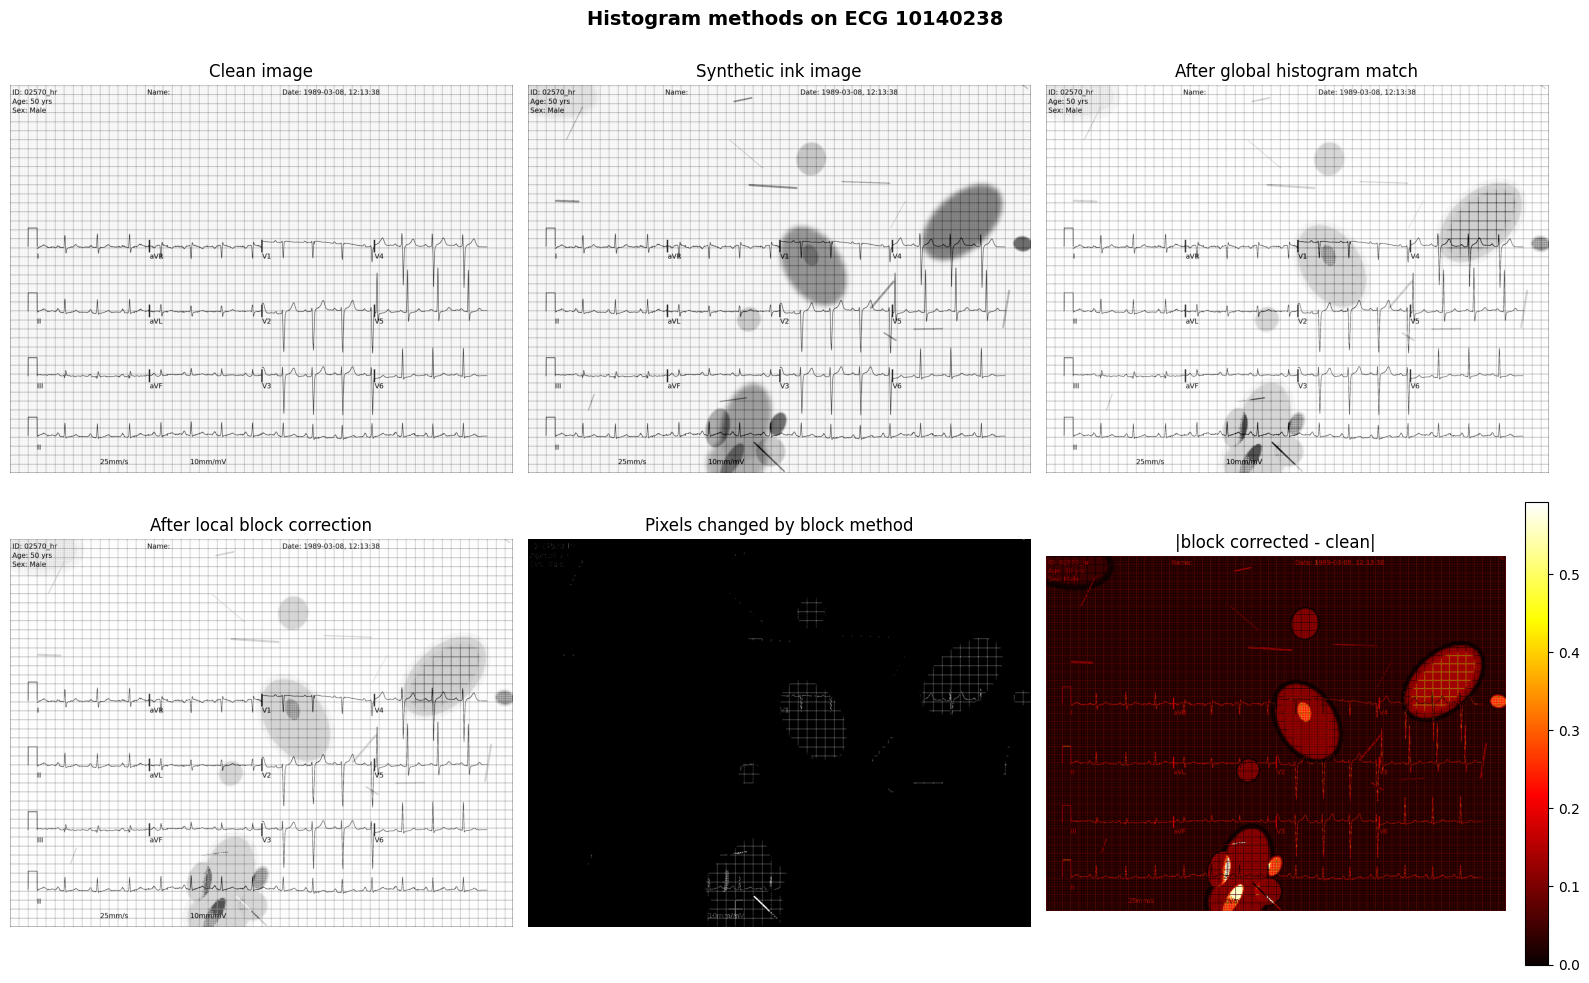

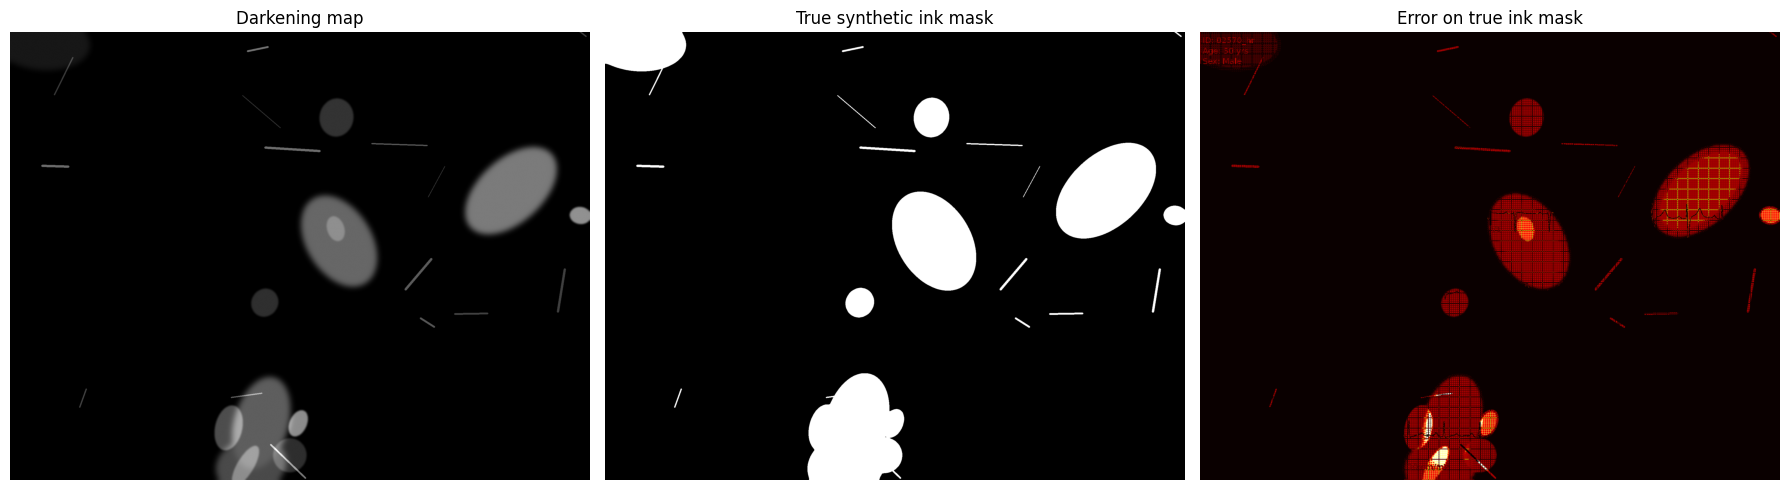

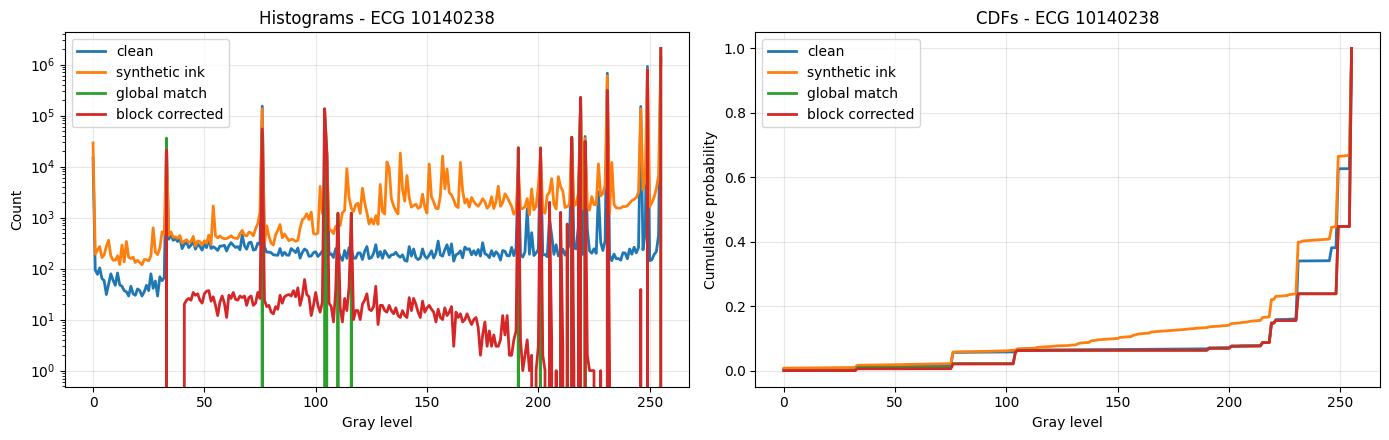

ECG ID: 11842146
  clean path        : ..\..\data\sample\11842146\11842146-0001.png
  synthetic seed    : 19
  shape             : (1700, 2200)
  true ink pixels   : 336648
  MAE before on all : 0.015498
  MAE global on all : 0.029601
  MAE block on all  : 0.029218
  MAE before on ink : 0.169262
  MAE global on ink : 0.078692
  MAE block on ink  : 0.074435


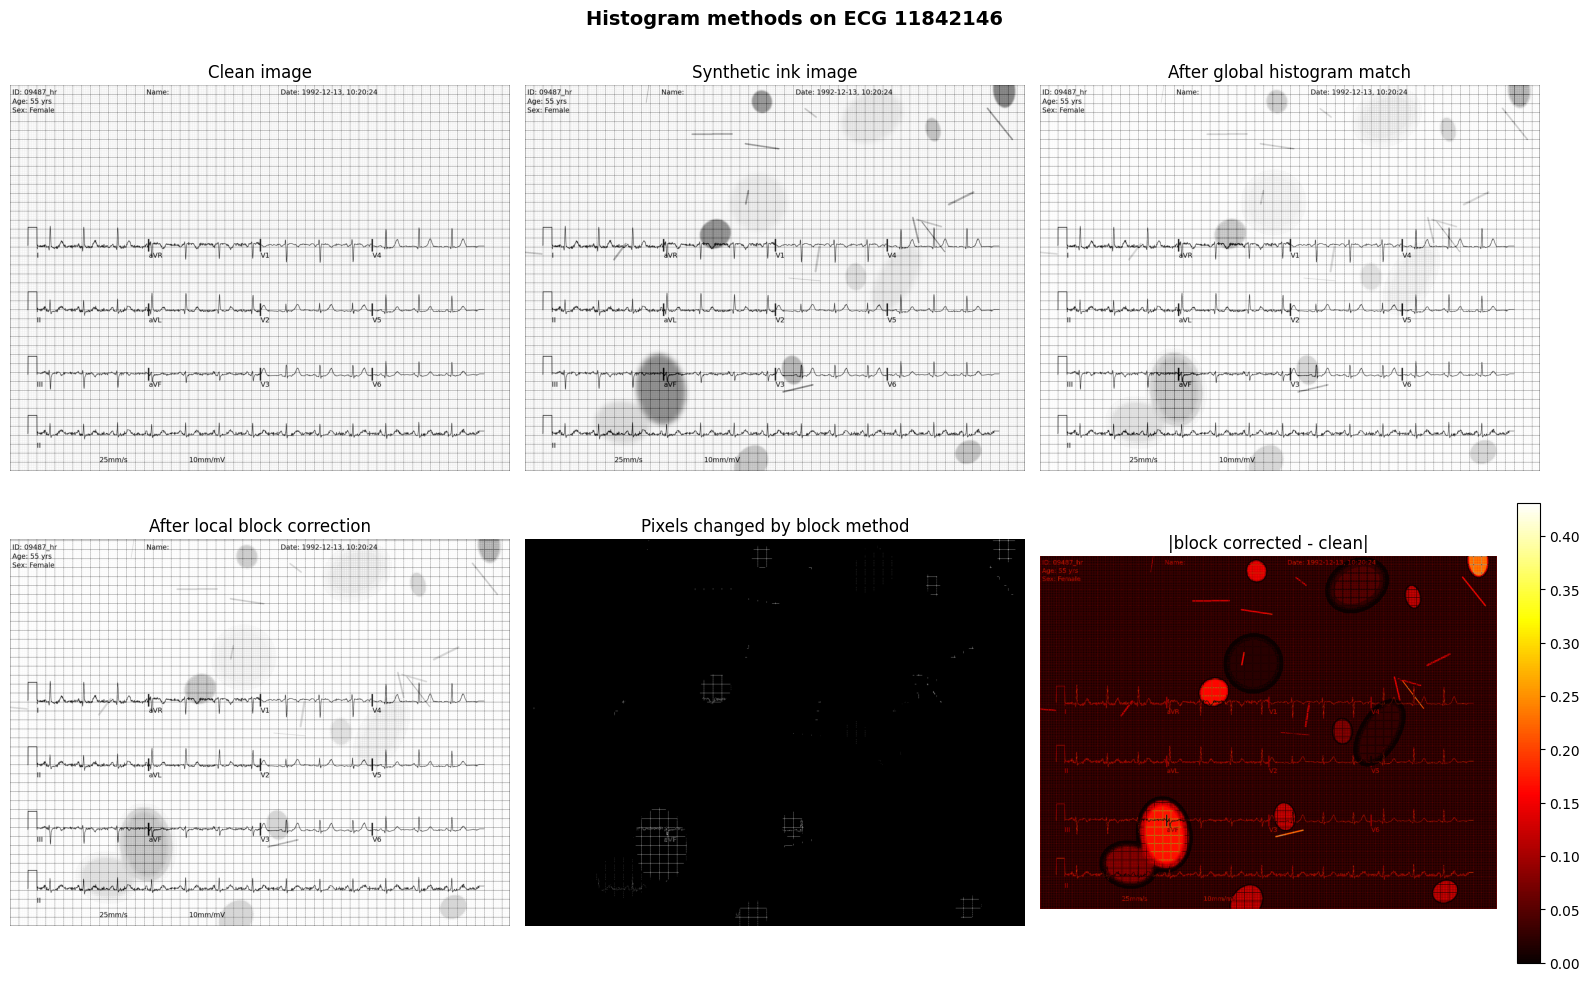

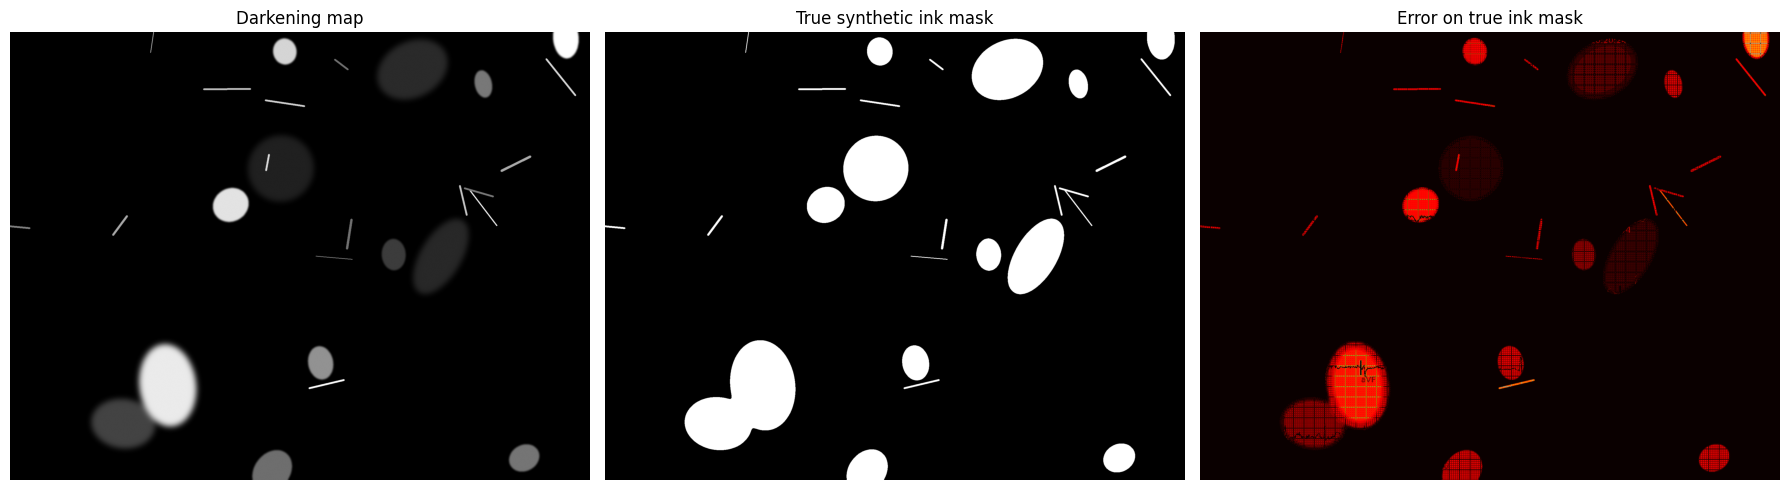

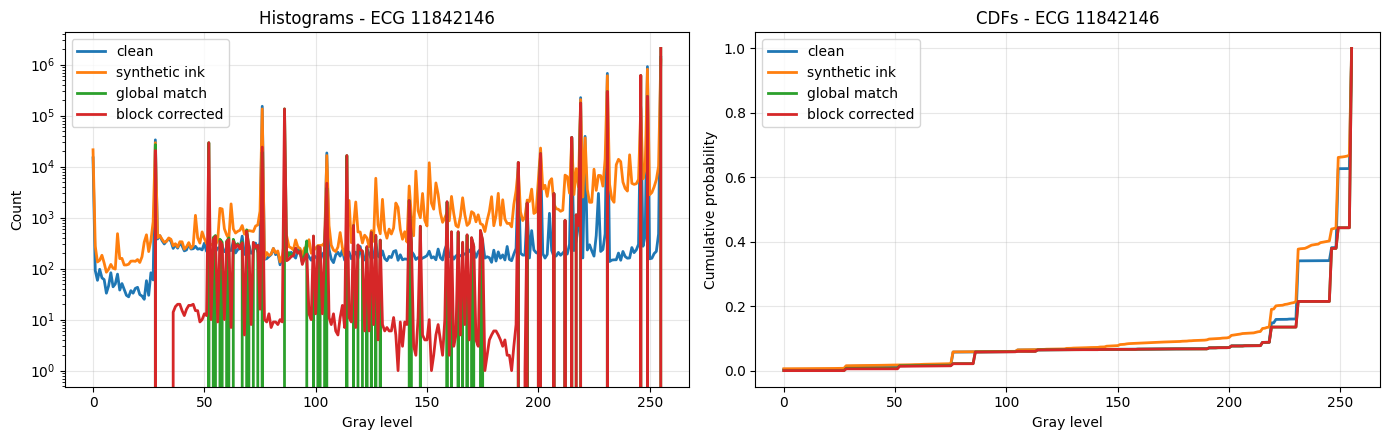

In [3]:
results = []
for ecg_id in ecg_ids:
    results.append(
        process_pair(
            ecg_id,
            seed=SEEDS[ecg_id],
            block_size=BLOCK_SIZE,
            bin_width=BIN_WIDTH,
            dark_max=DARK_MAX,
            value_margin=VALUE_MARGIN,
        )
    )


### Conclusion

Saved result on `11842146`:
- before processing: all-pixel MAE `0.015498`, ink-mask MAE `0.169262`
- global histogram match: all-pixel MAE `0.029601`, ink-mask MAE `0.078692`
- block histogram correction: all-pixel MAE `0.029218`, ink-mask MAE `0.074435`

So the histogram method helps on the ink region, and the block version is slightly better than global matching.
But both versions still make the full image worse.
For this synthetic case, histogram correction is useful as an intermediate baseline, but it is weaker than black-hat restoration.
